#ACTIVIDAD 5
##Validación de categorización de docentes de un programa académico
###Patricia Fonseca Sánchez

##Planteamiento
El estudio de caso busca validar la categorización de los docentes de un programa académico a partir del cruce de dos fuentes de información: un listado institucional de docentes identificado por número de documento y una base de resultados de categorización de Minciencias.

El análisis permite determinar qué docentes aparecen categorizados en la base de Minciencias, cuáles no presentan una categoría y cómo se distribuyen las categorías encontradas. Esta tarea contribuye a la gestión de presentación de proyectos a convocatorias.

La llave utilizada para realizar el cruce es el número de documento.

##Objetivo
Validar, mediante Python y pandas, la correspondencia entre el listado de docentes del programa y la información de categorización disponible en la base de Minciencias, generando indicadores de cobertura y una evidencia visual de los resultados.

#Proceso de análisis
Se revisa la estructura y calidad de las bases, se identifican duplicados y se eliminan de la
base institucional (docentes), renombra la variable de categoría y una un merge para cruzar las dos bases conservando los docentes institucionales.
Finalmente calcula indicadores, reemplaza los valores faltantes por N.A. y genera archivos de salida y visualizaciones.

## Retos Futuros
Este ejercicio puede ser complementado con bases de información adicionales, tales como convocatorias de Minciencias y datos demográficos o contractuales de la planta docente (vinculación activa, pertenencia a grupos de investigación y producción científica). Integrar estas fuentes de datos permitiría alcanzar los siguientes objetivos:

- **Optimización de recursos**: Reducir reprocesos administrativos y de los docentes para optimizar tiempos y costos.
- **Calidad de la información**: Contar con un registro de la producción científica docente actualizado y veraz.
- **Interoperabilidad tecnológica**: Conectar de forma eficiente los sistemas de investigación institucionales con la plataforma SCIENTI.
- **Impacto institucional**: Incrementar la visibilidad de la universidad y potenciar la participación en convocatorias de financiación internas y externas.



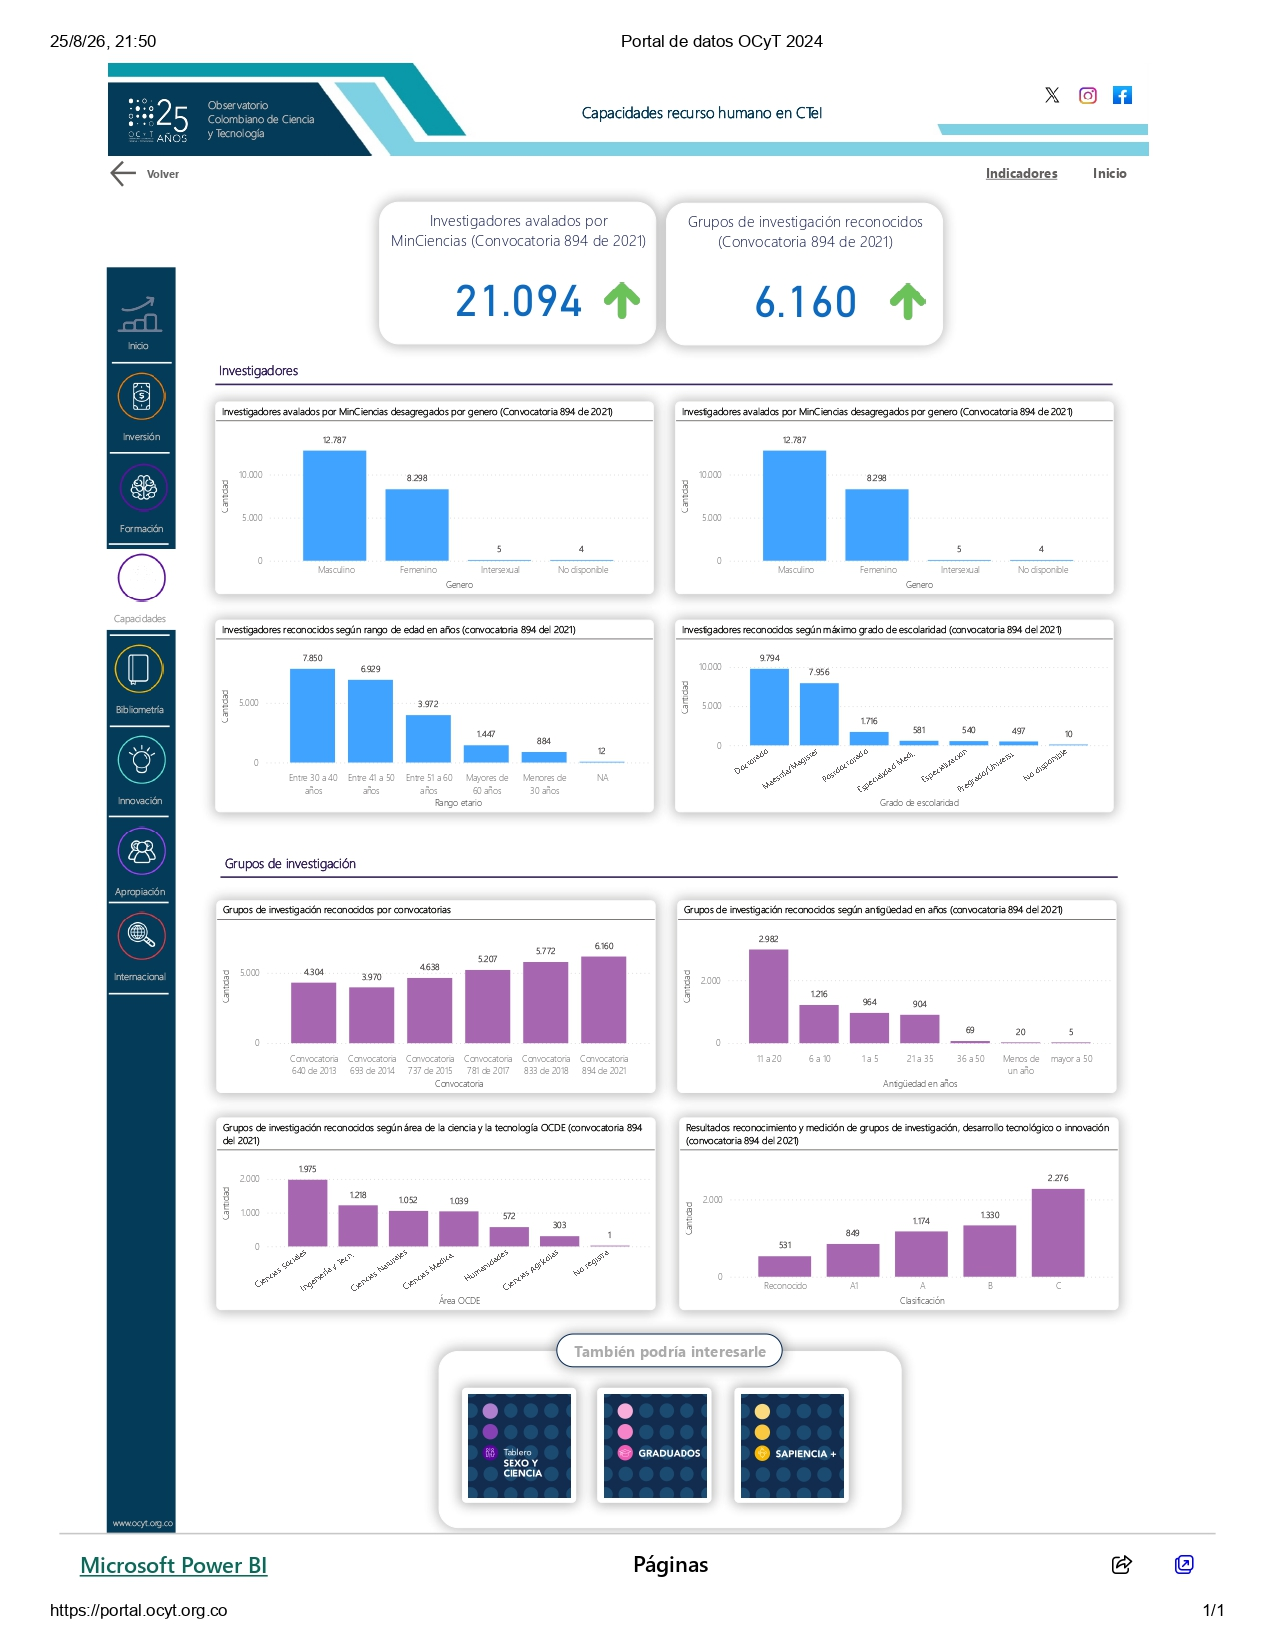

In [ ]:
#Importar librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#Cargar las bases de datos

In [ ]:
import pandas as pd

# base 2 listado de resultados de categoría minciencias

url = 'https://raw.githubusercontent.com/PatriciaFS167/Actividad5-Fonseca-Patricia-/main/convocatoriaa.csv'

# nrows limita la lectura a las primeras filas
minciencias = pd.read_csv(url, sep=";",encoding='latin1')
minciencias.shape

(25514, 2)

In [ ]:
## base # 2 que es listado de docentes solicitados

# Corrected URL to raw CSV data on GitHub
url = 'https://raw.githubusercontent.com/PatriciaFS167/Actividad5-Fonseca-Patricia-/main/muestras.csv'

# nrows limita la lectura a las primeras filas
docentes = pd.read_csv(url, sep=";", encoding='latin1')
docentes.shape

(40, 1)

#Revisar las columnas de cada base

In [ ]:
#validar el nombre de las columnas de la base minciencias
minciencias.columns

Index(['documento', 'tipo de investigador'], dtype='object')

In [ ]:
#validar el nombre de las columnas de la base docentes
docentes.columns

Index(['documento'], dtype='object')

In [ ]:
# revisar las primeras 5 filas de la base minciencias
minciencias.head()

,documento,tipo de investigador
0,610891090,Investigador Sénior (IS)
1,668365730,Investigador Asociado (I)
2,3383839,Investigador Junior (IJ)
3,30180796,Investigador Sénior (IS)
4,03464606R,Investigador Sénior (IS)


In [ ]:
# revisar las primeras 5 filas de la base docentes
docentes.head()

,documento
0,52848924
1,53120854
2,1013614554
3,79800628
4,79557883


#Tipos de dato

In [ ]:
# ¿Qué tipo asignó pandas a cada columna en la base miciencias?

minciencias.dtypes.head()

,0
documento,object
tipo de investigador,object


In [ ]:
# ¿Qué tipo asignó pandas a cada columna en la base docentes?

docentes.dtypes.head()

,0
documento,int64


In [ ]:
#Convertir los valores de la columna documento a texto (string) de la base docentes

docentes["documento"] = (
    docentes["documento"]
    .astype(str)
    .str.strip()
)

In [ ]:
#Convertir los valores de la columna documento a texto (string) de la base minciencias
minciencias["documento"] = (
    minciencias["documento"]
    .astype(str)
    .str.strip()
)

In [ ]:
# Verifiacar el cambio realizado en el tipo de dato de ambas bases

print(docentes["documento"].dtype)
print(minciencias["documento"].dtype)

print(docentes["documento"].head())
print(minciencias["documento"].head())

object
object
0      52848924
1      53120854
2    1013614554
3      79800628
4      79557883
Name: documento, dtype: object
0    610891090
1    668365730
2      3383839
3     30180796
4    03464606R
Name: documento, dtype: object


In [ ]:
# Revisar la estructura de la base minciencias

minciencias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25514 entries, 0 to 25513
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   documento             25514 non-null  object
 1   tipo de investigador  25514 non-null  object
dtypes: object(2)
memory usage: 398.8+ KB


In [ ]:
# Revisar la estructura de la base docentes

docentes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   documento  40 non-null     object
dtypes: object(1)
memory usage: 452.0+ bytes


In [ ]:
# Cuántos faltantes tiene cada columna
faltantes = minciencias.isna().sum()
faltantes[faltantes > 0]

faltantes = docentes.isna().sum()
faltantes[faltantes > 0]

,0


In [ ]:
# Cuántas filas están repetidas en la base minciencias?
minciencias.duplicated().sum()

np.int64(0)

In [ ]:
 #Cuántas filas están repetidas en la base docentes?
docentes.duplicated().sum()

np.int64(2)

In [ ]:
# Para saber cuáles son las dos filas duplicadas

docentes[docentes.duplicated(keep=False)]

,documento
12,19063801
13,19063801
24,79570878
25,79570878


In [ ]:
#Eliminar las filas duplicadas , creando un nuevo DataFrame

docentes_limpio = docentes.drop_duplicates()

In [ ]:
#Para comprobar que las filas duplicadas se eliminaron

docentes_limpio.duplicated().sum()

np.int64(0)

In [ ]:
#Cambiar el nombre de la columna "tipo de investigador"
# Para que sea más fácil de interpretar,cambiamos "tipo de investigador" por "categoria".

minciencias = minciencias.rename(columns={"tipo de investigador": "categoria"})

minciencias.shape
minciencias.columns

Index(['documento', 'categoria'], dtype='object')

In [ ]:
# Cómo están escritas realmente las categorías

minciencias['categoria'].value_counts(dropna=False)

,count
categoria,
Investigador Junior (IJ),15411
Investigador Asociado (I),5542
Investigador Sénior (IS),4437
Investigador Emérito (IE),124


In [ ]:
#Seleccionar las columnas de trabajo

columnas = ["documento", "categoria"]

minciencias_final= minciencias[columnas].copy()

minciencias_final.shape

(25514, 2)

In [ ]:
minciencias_final["documento"].duplicated().sum()

np.int64(0)

In [ ]:
#Cruzar las dos bases

#on="documento" indica que las bases se cruzan utilizando el número de documento.
# how="left" significa que conservamos todos los docentes de la Universidad y buscamos su información en la base de Minciencias
# validate='many_to_one' detiene el proceso si el documento está repetido en la base

resultado = docentes_limpio.merge(
    minciencias_final,
    on="documento",
    how="left",
    validate='many_to_one')

resultado.shape

(38, 2)

In [ ]:
#Cúantos docentes fueron categorizados y cuántos no?

encontrados = resultado["categoria"].notna().sum()

no_encontrados = resultado["categoria"].isna().sum()

print("Docentes categorizados:", encontrados)
print("Docentes no categorizados:", no_encontrados)

Docentes categorizados: 14
Docentes no categorizados: 24


In [ ]:
#Determinar el porcentaje de categorizados
Porcentaje_categorizados = (encontrados / len(docentes_limpio)*100)
print(f"Porcentaje de docentes categorizados: {Porcentaje_categorizados:.2f}%")


Porcentaje de docentes categorizados: 36.84%


In [ ]:
#Deternar el porcentaje de no categorizados
Porcentaje_no_categorizados = (no_encontrados / len(docentes_limpio)*100)
print(f"Porcentaje de docentes no categorizados: {Porcentaje_no_categorizados:.2f}%")

Porcentaje de docentes no categorizados: 63.16%


#Verificación de calidad

In [ ]:
resultado.columns

Index(['documento', 'categoria'], dtype='object')

In [ ]:
print('filas iniciales:', docentes.shape[0])
print('filas finales:', resultado.shape[0])
print('filas eliminadas:', docentes.shape[0] - resultado.shape[0])

filas iniciales: 40
filas finales: 38
filas eliminadas: 2


In [ ]:
#Revisar las filas duplicadas
resultado.duplicated().sum()

np.int64(0)

#Comprobación sobre la tabla limpia

In [ ]:
#Agrupación de datos basándose en los valores únicos de la columna categoria

resumen = resultado.groupby("categoria")["documento"].count()
resumen

,documento
categoria,
Investigador Asociado (I),5
Investigador Junior (IJ),7
Investigador Sénior (IS),2


In [ ]:
#mostrar las primeras 40 filas de resultados

display(resultado.head(40))

,documento,categoria
0,52848924,NaN
1,53120854,NaN
2,1013614554,NaN
3,79800628,NaN
4,79557883,NaN
5,1113636417,NaN
6,80194995,Investigador Asociado (I)
7,19268144,NaN
8,19494483,NaN
9,1015433481,Investigador Junior (IJ)


In [ ]:
# Cambiar los valores NaN por N.A.

resultado_final = resultado.fillna("N.A")

# Mostrar nuevamente las primeras 40 filas
display(resultado_final.head(40))

,documento,categoria
0,52848924,N.A
1,53120854,N.A
2,1013614554,N.A
3,79800628,N.A
4,79557883,N.A
5,1113636417,N.A
6,80194995,Investigador Asociado (I)
7,19268144,N.A
8,19494483,N.A
9,1015433481,Investigador Junior (IJ)


#Cargar

In [ ]:
# Guarda un archivo en formato CSV con título docentes reconocidos
resultado_final.to_csv('docentes_reconocidos.csv', index=False)

print("Archivo CVS creado exitosamente")

Archivo CVS creado exitosamente


In [ ]:
# utf-8-sig hace que Excel abra bien las tildes en Windows
resultado.to_csv('docentes_reconocidos.csv', index=False, encoding='utf-8-sig')

categoria
Investigador Asociado (I)    5
Investigador Junior (IJ)     7
Investigador Sénior (IS)     2
Name: documento, dtype: int64


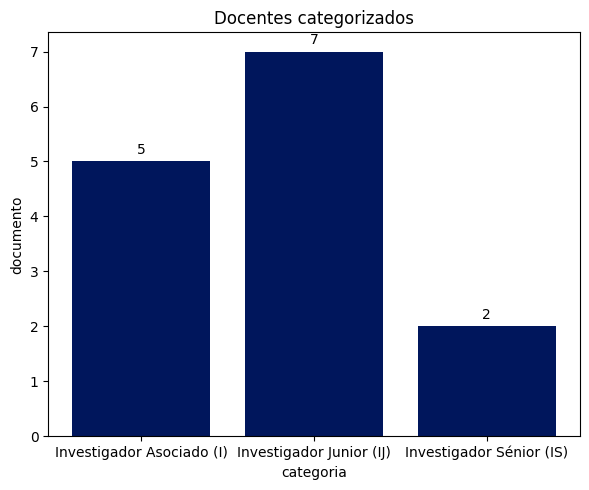

In [ ]:
# Agrupar la tabla resultado usando la columna categoria
resumen = resultado.groupby('categoria')['documento'].count()

print(resumen)

figura, eje = plt.subplots(figsize=(6, 5))  # Crear la figura y el eje
barras = eje.bar(resumen.index, resumen.values, color='#00165C')  # Dibujar el gráfico de barras

eje.set_title('Docentes categorizados')
eje.set_xlabel('categoria')
eje.set_ylabel('documento')
plt.tight_layout()

eje.bar_label(barras, padding=3)

plt.show()

In [ ]:
# dpi controla la resolución y bbox_inches evita que se corten los rótulos
figura.savefig('docentes por categoria.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
Estado_categorización = ['Docentes categorizados', 'Docentes no categorizados']
valores = [36.84, 63.16]

# Conclusiones

De los 40 registros iniciales se identificaron 2 duplicados, por lo que el análisis final se realizó sobre 38 registros únicos. De estos, 14 presentan una categoría encontrada en la base de Minciencias y 24 no presentan una
categoría encontrada.
La cobertura observada de categorización es, por tanto, del 36,84 %, mientras que el 63,16% requiere revisión o no tiene una categoría identificada en la fuente consultada.

Dentro de los docentes categorizados, Investigador Junior (IJ) es la categoría más frecuente con 7 casos (50 % de los categorizados), seguida de Investigador Asociado (I) con 5 casos (35,71 %) e Investigador Sénior (IS) con 2 casos (14,29 %).

Trabajos futuros:

* Realizar el cruce una tercera base de datos adicional integrando el Grupo de investigación al que pertenecen.
* Realizar el cruce una cuarta y quinta base de datos de los resultados de una convoactoria anterior y verifiacr si es docente activo o no de la Institución.
* Asociar un listado de docentes a la base de productos de la Institución.